In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings("ignore")

# データ読み込み
sales_df = pd.read_csv("../data/raw/sales.csv")
detail_df = pd.read_csv("../data/raw/sale_details.csv")

# 日付の型変換
sales_df["date"] = pd.to_datetime(sales_df["date"])

print("読み込み完了")
print(f"sales_df: {len(sales_df):,}件")

読み込み完了
sales_df: 32,467件


In [2]:
# 日別に集計（1日1レコードにする）
daily_df = sales_df.groupby("date").agg(
    total=("total", "sum"),
    customers=("sale_id", "count"),
    temperature=("temperature", "mean")
).reset_index()

# 特徴量の追加
daily_df["day_of_week"] = daily_df["date"].dt.dayofweek  # 曜日（0=月〜6=日）
daily_df["month"] = daily_df["date"].dt.month            # 月
daily_df["year"] = daily_df["date"].dt.year              # 年
daily_df["is_weekend"] = (daily_df["day_of_week"] >= 5).astype(int)  # 土日フラグ

# 天気をダミー変数に変換
weather_dummies = pd.get_dummies(sales_df.groupby("date")["weather"].first(), prefix="weather")
daily_df = daily_df.merge(weather_dummies, on="date")

print(daily_df.head())
print(f"\n特徴量数：{len(daily_df.columns)}列")
print(f"レコード数：{len(daily_df):,}件")

        date  total  customers  temperature  day_of_week  month  year  \
0 2023-01-01  60400         47          6.0            6      1  2023   
1 2023-01-02  44100         35          2.8            0      1  2023   
2 2023-01-03  44750         37          8.2            1      1  2023   
3 2023-01-04  40350         33          3.8            2      1  2023   
4 2023-01-05  29650         24          5.5            3      1  2023   

   is_weekend  weather_晴れ  weather_曇り  weather_雨  weather_雪  
0           1       False        True      False      False  
1           0        True       False      False      False  
2           0        True       False      False      False  
3           0        True       False      False      False  
4           0       False        True      False      False  

特徴量数：12列
レコード数：731件


In [3]:
# 特徴量と目的変数の設定
feature_cols = [
    "day_of_week", "month", "year", "temperature",
    "is_weekend", "weather_晴れ", "weather_曇り", "weather_雨", "weather_雪"
]

target_col = "total"

X = daily_df[feature_cols]
y = daily_df[target_col]

# 学習・テストデータに分割（時系列なので末尾20%をテストに）
split_idx = int(len(daily_df) * 0.8)
X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

print(f"学習データ：{len(X_train)}件")
print(f"テストデータ：{len(X_test)}件")

# LightGBMで学習
model = lgb.LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    verbose=-1
)
model.fit(X_train, y_train)

# 予測・評価
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print(f"\n=== モデル評価 ===")
print(f"MAE  : ¥{mae:,.0f}円")
print(f"RMSE : ¥{rmse:,.0f}円")
print(f"MAPE : {mape:.1f}%")

学習データ：584件
テストデータ：147件

=== モデル評価 ===
MAE  : ¥4,906円
RMSE : ¥6,309円
MAPE : 9.5%


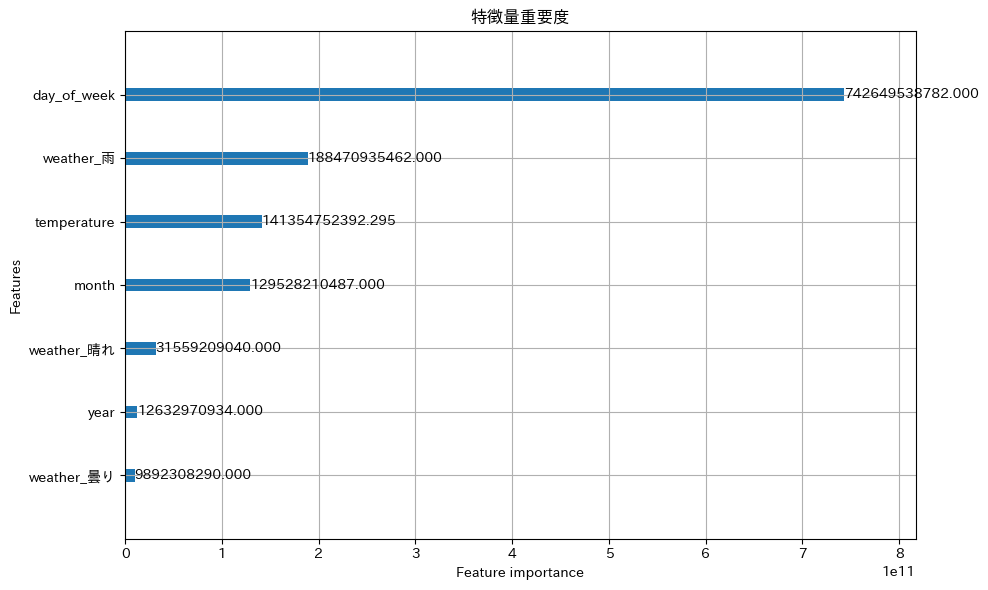

In [4]:
# 特徴量重要度の可視化
fig, ax = plt.subplots(figsize=(10, 6))
lgb.plot_importance(model, ax=ax, importance_type="gain", title="特徴量重要度")
plt.tight_layout()
plt.show()

In [5]:
import pickle
import os

# 保存先フォルダの作成
os.makedirs("../ml/models", exist_ok=True)

# モデルの保存
with open("../ml/models/sales_model.pkl", "wb") as f:
    pickle.dump(model, f)

# 特徴量リストも保存（予測時に使うため）
with open("../ml/models/feature_cols.pkl", "wb") as f:
    pickle.dump(feature_cols, f)

print("モデルの保存完了！")
print(f"保存先：../ml/models/sales_model.pkl")

モデルの保存完了！
保存先：../ml/models/sales_model.pkl
